In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
# Load the dataset
data = pd.read_csv("../../data/Test Data.csv")


In [3]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')


In [4]:
data.set_index('Date', inplace=True)

In [5]:
# Group by 'Date' and calculate the average for each column
data_avg = data.groupby('Date').mean()

In [6]:
data_avg

,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
Date,,,,,,,,,,,,,,,
2022-09-01,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848.0,251968.1429,393.651786,32890183.17,37.050402,4142157.11
2022-09-02,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313.0,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2022-09-03,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565.0,246798.6027,388.062500,33383868.74,36.708884,4281017.27
2022-09-04,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303.0,257327.6563,387.245536,32606986.82,36.628527,4140106.66
2022-09-05,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314.0,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-28,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629.0,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
2023-08-29,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688.0,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
2023-08-30,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111.0,133872.1556,362.741936,65854384.38,40.078159,7464569.80


In [19]:
# Select the columns for modeling
variables = data_avg[['User Count Average', 'Traffic', 'Average User Throughput DL']]

# Normalize the data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(variables)

# Convert the scaled data back to a DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=variables.columns, index=variables.index)

# Create sequences of data for LSTM (e.g., using 10 previous timesteps to predict the next one)
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, -1])  # Predicting 'Average User Throughput DL'
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(scaled_data.values, seq_length)

# Split the data into training and testing sets
train_size = int(X.shape[0] * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Hyperparameter Tuning
lstm_units = [32, 50, 64, 128]  # Values to try for LSTM units
batch_sizes = [16, 32, 64]  # Values to try for batch size

# Evaluate different hyperparameter combinations
for units in lstm_units:
  for batch_size in batch_sizes:
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)


    model.fit(X_train, y_train, batch_size=batch_size, epochs=100, validation_split=0.2, callbacks=[early_stopping])

    # Evaluate and record performance for each configuration


Epoch 1/100
13/13 [==============================] - 7s 91ms/step - loss: 0.0545 - val_loss: 0.0219
Epoch 2/100
13/13 [==============================] - 0s 11ms/step - loss: 0.0113 - val_loss: 0.0097
Epoch 3/100
13/13 [==============================] - 0s 10ms/step - loss: 0.0064 - val_loss: 0.0087
Epoch 4/100
13/13 [==============================] - 0s 10ms/step - loss: 0.0049 - val_loss: 0.0065
Epoch 5/100
13/13 [==============================] - 0s 11ms/step - loss: 0.0040 - val_loss: 0.0101
Epoch 6/100
13/13 [==============================] - 0s 13ms/step - loss: 0.0038 - val_loss: 0.0074
Epoch 7/100
13/13 [==============================] - 0s 13ms/step - loss: 0.0036 - val_loss: 0.0090
Epoch 8/100
13/13 [==============================] - 0s 13ms/step - loss: 0.0034 - val_loss: 0.0072
Epoch 9/100
13/13 [==============================] - 0s 14ms/step - loss: 0.0035 - val_loss: 0.0110
Epoch 1/100
7/7 [==============================] - 7s 184ms/step - loss: 0.0431 - val_loss: 0.0292
E

Epoch 4/100
4/4 [==============================] - 0s 26ms/step - loss: 0.0045 - val_loss: 0.0088
Epoch 5/100
4/4 [==============================] - 0s 26ms/step - loss: 0.0085 - val_loss: 0.0089
Epoch 6/100
4/4 [==============================] - 0s 27ms/step - loss: 0.0065 - val_loss: 0.0064
Epoch 7/100
4/4 [==============================] - 0s 26ms/step - loss: 0.0043 - val_loss: 0.0127
Epoch 8/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0052 - val_loss: 0.0101
Epoch 9/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0040 - val_loss: 0.0064
Epoch 10/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0038 - val_loss: 0.0062
Epoch 11/100
4/4 [==============================] - 0s 26ms/step - loss: 0.0038 - val_loss: 0.0071
Epoch 12/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0035 - val_loss: 0.0085
Epoch 13/100
4/4 [==============================] - 0s 26ms/step - loss: 0.0035 - val_loss: 0.0080
Epoch 14/100
4/4

In [22]:

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions and actual values
y_train_inv = scaler.inverse_transform(np.concatenate([X_train[:, -1, :-1], train_predict], axis=1))[:, -1]
y_test_inv = scaler.inverse_transform(np.concatenate([X_test[:, -1, :-1], test_predict], axis=1))[:, -1]
y_train_actual = scaler.inverse_transform(np.concatenate([X_train[:, -1, :-1], y_train.reshape(-1, 1)], axis=1))[:, -1]
y_test_actual = scaler.inverse_transform(np.concatenate([X_test[:, -1, :-1], y_test.reshape(-1, 1)], axis=1))[:, -1]

# Evaluate the model
mse_train = mean_squared_error(y_train_actual, y_train_inv)
mse_test = mean_squared_error(y_test_actual, y_test_inv)

4/4 [==============================] - 0s 11ms/step


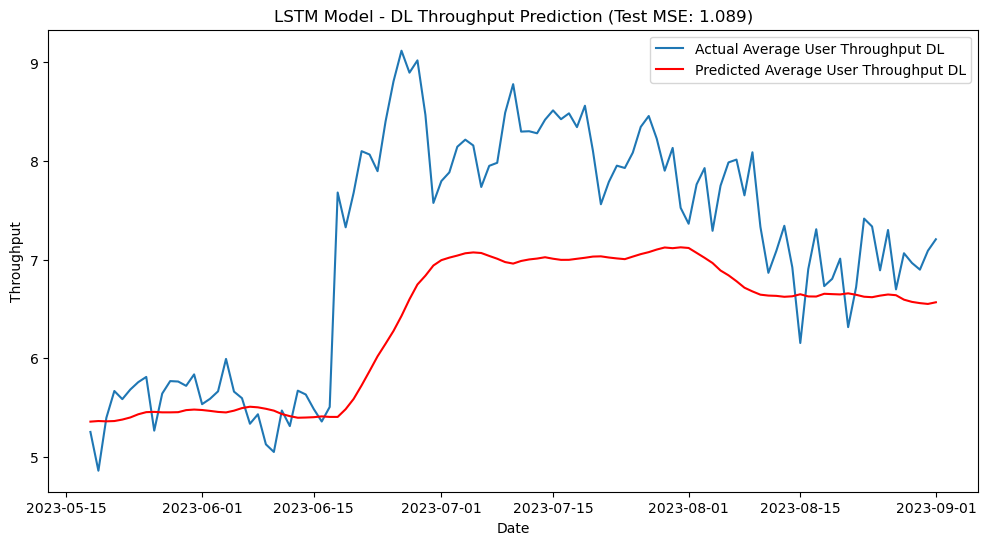

In [23]:
# Plot the results for testing data
plt.figure(figsize=(12, 6))
plt.plot(variables.index[train_size + seq_length:], y_test_actual, label='Actual Average User Throughput DL')
plt.plot(variables.index[train_size + seq_length:], y_test_inv, label='Predicted Average User Throughput DL', color='red')
plt.title(f'LSTM Model - DL Throughput Prediction (Test MSE: {mse_test:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()
# Save the results for testing data as per LSTM
#plt.savefig("Actual Vs Predict_TP_LSTM.png")  # Customize filename

In [24]:
# Print MSE for both training and testing
print(f'MSE on Training Data: {mse_train:.3f}')
print(f'MSE on Testing Data: {mse_test:.3f}')

MSE on Training Data: 0.162
MSE on Testing Data: 1.089


In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate MSE for the validation (test) data
mse_test = mean_squared_error(y_test_actual, y_test_inv)

# Calculate RMSE (Root Mean Squared Error) for the validation (test) data
rmse_test = np.sqrt(mse_test)

# Calculate MSE for the validation (test) data
mse_train = mean_squared_error(y_train_actual, y_train_inv)

# Calculate RMSE (Root Mean Squared Error) for the validation (test) data
rmse_train = np.sqrt(mse_train)

print(f'MSE on Testing Data: {mse_test:.3f}')
print(f'RMSE on Testing Data: {rmse_test:.3f}')
print(f'MSE on Training Data: {mse_train:.3f}')
print(f'RMSE on Training Data: {rmse_train:.3f}')

MSE on Testing Data: 1.089
RMSE on Testing Data: 1.043
MSE on Training Data: 0.162
RMSE on Training Data: 0.403


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Hyperparameter Tuning
lstm_units = [32, 50, 64, 128]  # Values to try for LSTM units
batch_sizes = [16, 32, 64]  # Values to try for batch size

# Evaluate different hyperparameter combinations
for units in lstm_units:
  for batch_size in batch_sizes:
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)


    model.fit(X_train, y_train, batch_size=batch_size, epochs=100, validation_split=0.2, callbacks=[early_stopping])

    # Evaluate and record performance for each configuration


Epoch 1/100
13/13 [==============================] - 6s 89ms/step - loss: 0.0559 - val_loss: 0.0188
Epoch 2/100
13/13 [==============================] - 0s 14ms/step - loss: 0.0116 - val_loss: 0.0096
Epoch 3/100
13/13 [==============================] - 0s 11ms/step - loss: 0.0067 - val_loss: 0.0059
Epoch 4/100
13/13 [==============================] - 0s 13ms/step - loss: 0.0051 - val_loss: 0.0060
Epoch 5/100
13/13 [==============================] - 0s 12ms/step - loss: 0.0040 - val_loss: 0.0067
Epoch 6/100
13/13 [==============================] - 0s 11ms/step - loss: 0.0035 - val_loss: 0.0068
Epoch 7/100
13/13 [==============================] - 0s 12ms/step - loss: 0.0032 - val_loss: 0.0083
Epoch 8/100
13/13 [==============================] - 0s 11ms/step - loss: 0.0032 - val_loss: 0.0098
Epoch 1/100
7/7 [==============================] - 7s 169ms/step - loss: 0.0608 - val_loss: 0.0071
Epoch 2/100
7/7 [==============================] - 0s 14ms/step - loss: 0.0177 - val_loss: 0.0203
Epo

Epoch 5/100
4/4 [==============================] - 0s 22ms/step - loss: 0.0101 - val_loss: 0.0113
Epoch 6/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0076 - val_loss: 0.0062
Epoch 7/100
4/4 [==============================] - 0s 28ms/step - loss: 0.0044 - val_loss: 0.0135
Epoch 8/100
4/4 [==============================] - 0s 22ms/step - loss: 0.0064 - val_loss: 0.0122
Epoch 9/100
4/4 [==============================] - 0s 22ms/step - loss: 0.0046 - val_loss: 0.0064
Epoch 10/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0041 - val_loss: 0.0063
Epoch 11/100
4/4 [==============================] - 0s 28ms/step - loss: 0.0048 - val_loss: 0.0061
Epoch 12/100
4/4 [==============================] - 0s 22ms/step - loss: 0.0039 - val_loss: 0.0078
Epoch 13/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0035 - val_loss: 0.0115
Epoch 14/100
4/4 [==============================] - 0s 21ms/step - loss: 0.0039 - val_loss: 0.0110
Epoch 15/100
4/

In [16]:
# Calculate MSE for the validation (test) data
mse_test = mean_squared_error(y_test_actual, y_test_inv)

# Calculate RMSE (Root Mean Squared Error) for the validation (test) data
rmse_test = np.sqrt(mse_test)

# Calculate MSE for the validation (test) data
mse_train = mean_squared_error(y_train_actual, y_train_inv)

# Calculate RMSE (Root Mean Squared Error) for the validation (test) data
rmse_train = np.sqrt(mse_train)

print(f'MSE on Testing Data: {mse_test:.3f}')
print(f'RMSE on Testing Data: {rmse_test:.3f}')
print(f'MSE on Training Data: {mse_train:.3f}')
print(f'RMSE on Training Data: {rmse_train:.3f}')

MSE on Testing Data: 0.483
RMSE on Testing Data: 0.695
MSE on Training Data: 0.146
RMSE on Training Data: 0.383


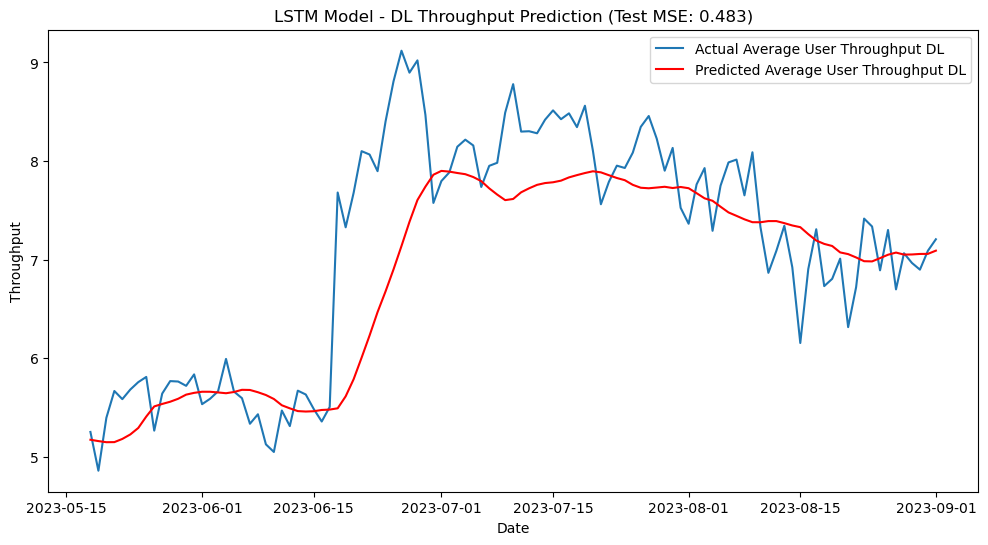

In [17]:
# Plot the results for testing data
plt.figure(figsize=(12, 6))
plt.plot(variables.index[train_size + seq_length:], y_test_actual, label='Actual Average User Throughput DL')
plt.plot(variables.index[train_size + seq_length:], y_test_inv, label='Predicted Average User Throughput DL', color='red')
plt.title(f'LSTM Model - DL Throughput Prediction (Test MSE: {mse_test:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()